In [1]:
print("Spam Message Detector")
print("Project started successfully!")

Spam Message Detector
Project started successfully!


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = {
    "message": [
        "Congratulations! You won a free prize",
        "Win a free mobile phone now",
        "Click here to claim your reward",
        "You have won 10000 rupees",
        "Free entry in our lucky draw",
        "Claim your free gift today",
        "URGENT! You have won a lottery",
        "Get free cash by clicking this link",
        "Congratulations, you are the lucky winner",
        "You have received a free voucher",

        "Hey, are you coming to class today?",
        "Please send me the assignment",
        "Can we meet tomorrow?",
        "What time is the meeting?",
        "I will call you later",
        "Don't forget to bring your notebook",
        "Happy birthday! Have a great day",
        "Are you free this evening?",
        "Please share the notes with me",
        "See you tomorrow"
    ],

    "label": [
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",

        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham",
        "ham"
    ]
}

df = pd.DataFrame(data)

df.head()

,message,label
0,Congratulations! You won a free prize,spam
1,Win a free mobile phone now,spam
2,Click here to claim your reward,spam
3,You have won 10000 rupees,spam
4,Free entry in our lucky draw,spam


In [4]:
print("Total messages:", len(df))

print("\nMessage categories:")
print(df["label"].value_counts())

Total messages: 20

Message categories:
label
spam    10
ham     10
Name: count, dtype: int64


In [12]:
print("Total messages:", len(df))

print("\nMessage categories:")
print(df["label"].value_counts())

Total messages: 20

Message categories:
label
spam    10
ham     10
Name: count, dtype: int64


In [13]:
X = df["message"]
y = df["label"]

print("Input messages:")
print(X.head())

print("\nLabels:")
print(y.head())

Input messages:
0    Congratulations! You won a free prize
1              Win a free mobile phone now
2          Click here to claim your reward
3                You have won 10000 rupees
4             Free entry in our lucky draw
Name: message, dtype: object

Labels:
0    spam
1    spam
2    spam
3    spam
4    spam
Name: label, dtype: object


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 16
Testing messages: 4


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 16
Testing messages: 4


In [16]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (16, 56)
Testing data shape: (4, 56)


In [17]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [18]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.50      0.50      0.50         2
        spam       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



In [20]:
message = input("Enter a message: ")

message_tfidf = vectorizer.transform([message])

prediction = model.predict(message_tfidf)

if prediction[0] == "spam":
    print("🚨 SPAM MESSAGE")
else:
    print("✅ NOT SPAM")

Enter a message: Hey, can you send me the class notes?
✅ NOT SPAM


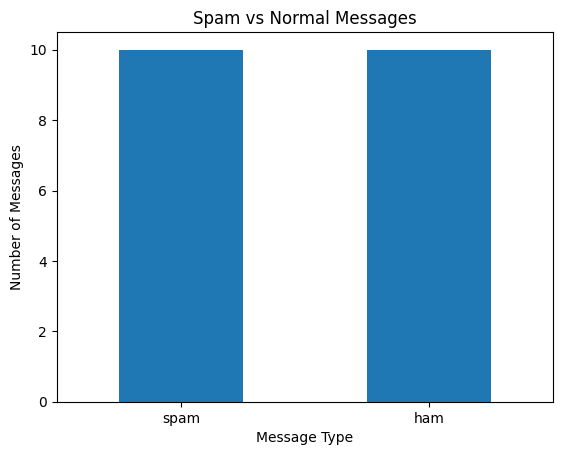

In [21]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Normal Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

In [22]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 1]
 [1 1]]


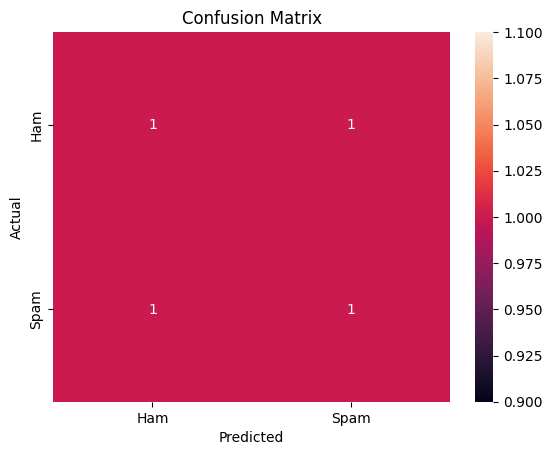

In [23]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
messages = [
    "Congratulations! You won a free prize",
    "Can you send me the assignment?",
    "Click here to claim your free money",
    "Are you coming to college tomorrow?",
    "You have won a lottery! Claim your reward"
]

messages_tfidf = vectorizer.transform(messages)

predictions = model.predict(messages_tfidf)

for message, prediction in zip(messages, predictions):
    print("Message:", message)
    print("Prediction:", prediction.upper())
    print("-" * 50)

Message: Congratulations! You won a free prize
Prediction: SPAM
--------------------------------------------------
Message: Can you send me the assignment?
Prediction: HAM
--------------------------------------------------
Message: Click here to claim your free money
Prediction: SPAM
--------------------------------------------------
Message: Are you coming to college tomorrow?
Prediction: HAM
--------------------------------------------------
Message: You have won a lottery! Claim your reward
Prediction: SPAM
--------------------------------------------------


Conclusion

In this project, I built a simple Spam Message Detector using Python and
Machine Learning. The model uses TF-IDF to convert text into numerical
features and Naive Bayes to classify messages as Spam or Not Spam.

This project helped me understand basic Natural Language Processing,
text classification, model training, and model evaluation.

Future Improvements

• Use a larger real-world SMS dataset.
• Improve text preprocessing.
• Try different machine learning algorithms.
• Build a simple web interface for the detector.
• Add support for multiple languages.
• Improve the model's accuracy with more training data.

In [5]:
X = df["message"]
y = df["label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 16
Testing messages: 4


In [7]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (16, 56)
Testing data shape: (4, 56)


In [8]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [9]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.50      0.50      0.50         2
        spam       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



In [11]:
message = input("Enter a message: ")

message_tfidf = vectorizer.transform([message])

prediction = model.predict(message_tfidf)

if prediction[0] == "spam":
    print("🚨 SPAM MESSAGE")
else:
    print("✅ NOT SPAM")

Enter a message: Congratulations! You won a free gift
🚨 SPAM MESSAGE
